
# ExaTrack Tutorial: Analyzing Single-Particle Tracking Data

ExaTrack is a powerful tool for analyzing single-particle tracking (SPT) data
using Hidden Markov Models. It can infer multiple diffusion states, transition
kinetics between states, and distinguish between different types of motion
(confined vs. directed).

This tutorial will guide you through the main functionalities of the package.

## Setup and Imports

First, let's import the necessary libraries and the ExaTrack module.


In [1]:
# %%
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm

# Import the ExaTrack module (ensure exatrack.py is in your path)
import sys
sys.path.append(r"C:\Users\Franc\Data\ExaTrack") # add exatrack directory to the system path
import exatrack

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow to use float64 for numerical precision
tf.keras.backend.set_floatx('float64')

# Check available devices
print("Available devices:")
print(tf.config.list_physical_devices())

# Use GPU if available, otherwise CPU
DEVICE = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f"\nUsing device: {DEVICE}")


Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Using device: /GPU:0


## Part 1: Generating Synthetic Data

Before fitting models, we need trajectory data. ExaTrack provides functions
to simulate tracks with multiple diffusion states and transitions between them.

We'll generate 2D tracks with:
- State 0: Confined motion (particles trapped in a potential well)
- State 1: Free Brownian diffusion

Key simulation parameters:
- `Ds`: Diffusion coefficients for each state
- `conf_forces`: Confinement strength (only relevant for confined states)
- `transition_matrix`: Rates of transitioning between states
- `LocErr`: Localization error (measurement noise)

In [2]:
nb_tracks = 1000          # Number of tracks to simulate
max_track_len = 50        # Maximum track length (time points)
dt = 0.02                 # Time interval between frames (seconds)
LocErr = 0.02             # Localization error (µm)
nb_dims = 2               # Number of spatial dimensions

# State parameters (2 states)
# State 0: Confined motion
# State 1: Free Brownian diffusion
Ds = np.array([0.05, 0.3])              # Diffusion coefficients (µm²/s)
conf_forces = np.array([0.3, 0.0])     # Confinement force (only state 0)
Fs = np.array([0.4, 0.6])              # Equilibrium fractions

# Transition matrix: transition_matrix[i,j] = rate of i -> j transition
# Diagonal elements are set to 0 (self-transitions handled differently)
transition_matrix = np.array([[0.00, 0.04],   # State 0 -> State 1
                              [0.06, 0.00]])  # State 1 -> State 0

# Shape matrix for gamma-distributed dwell times (shape=1 gives exponential)
shape_matrix = np.array([[0, 1],
                          [1, 0]])

print("Simulation Parameters:")
print(f"  Number of tracks: {nb_tracks}")
print(f"  Track length: {max_track_len}")
print(f"  Time step: {dt} s")
print(f"  Localization error: {LocErr} µm")
print(f"\nState Parameters:")
print(f"  Diffusion coefficients: {Ds} µm²/s")
print(f"  Confinement forces: {conf_forces}")
print(f"  Equilibrium fractions: {Fs}")

# %%
# Generate synthetic tracks using ExaTrack's simulation function
print("\nGenerating synthetic tracks...")

all_tracks, all_states, all_masks = exatrack.anomalous_diff_transition(
    max_track_len=max_track_len,
    nb_tracks=nb_tracks,
    LocErr=LocErr,
    Fs=Fs,
    Ds=Ds,
    nb_dims=nb_dims,
    velocities=np.array([0.0, 0.0]),      # No directed motion
    angular_Ds=np.array([0.0, 0.0]),      # No rotational diffusion
    conf_forces=conf_forces,
    conf_Ds=np.array([0.0, 0.0]),         # No diffusion of confinement center
    conf_dists=np.array([0.0, 0.0]),
    transition_matrix=transition_matrix,
    shape_matrix=shape_matrix,
    dt=dt,
    nb_sub_steps=10,  # Sub-steps for accurate simulation
    nb_burning_steps=0)

print(f"Generated tracks shape: {all_tracks.shape}")
print(f"States shape: {all_states.shape}")
print(f"Masks shape: {all_masks.shape}")

Simulation Parameters:
  Number of tracks: 1000
  Track length: 50
  Time step: 0.02 s
  Localization error: 0.02 µm

State Parameters:
  Diffusion coefficients: [0.05 0.3 ] µm²/s
  Confinement forces: [0.3 0. ]
  Equilibrium fractions: [0.4 0.6]

Generating synthetic tracks...
Generated tracks shape: (1000, 50, 2)
States shape: (1000, 50)
Masks shape: (1000, 50)


### Visualizing the Simulated Data

Let's visualize a few example tracks color-coded by their true states.

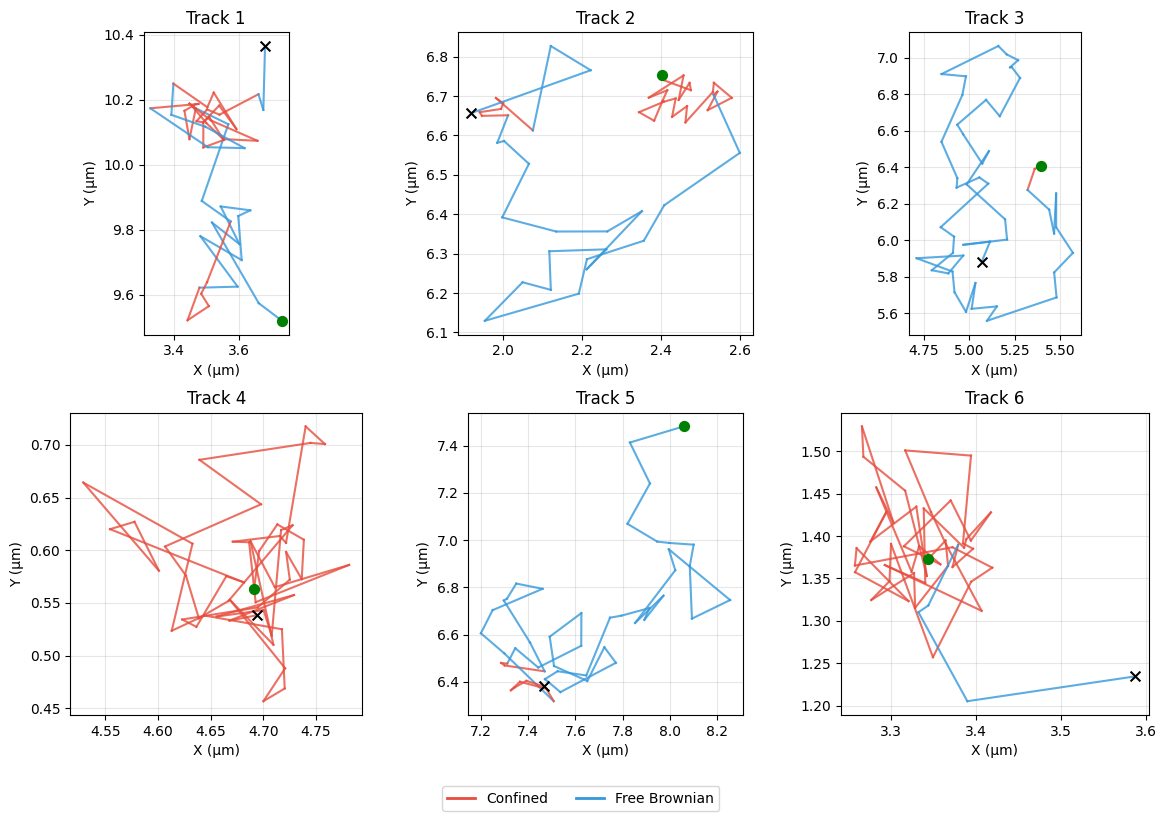

In [3]:
def plot_example_tracks(tracks, states, masks, n_examples=6):
    """Plot example tracks colored by state."""
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    colors = ['#e74c3c', '#3498db']  # Red for confined, blue for free
    state_names = ['Confined', 'Free Brownian']
    
    for idx, ax in enumerate(axes):
        if idx >= len(tracks):
            break
            
        track = tracks[idx]
        state = states[idx].astype(int)
        mask = masks[idx].astype(bool)
        
        # Plot track segments colored by state
        for i in range(np.sum(mask) - 1):
            ax.plot(track[i:i+2, 0], track[i:i+2, 1], 
                   color=colors[state[i]], linewidth=1.5, alpha=0.8)
        
        # Mark start and end
        ax.scatter(track[0, 0], track[0, 1], c='green', s=50, 
                  marker='o', zorder=5, label='Start')
        end_idx = int(np.sum(mask)) - 1
        ax.scatter(track[end_idx, 0], track[end_idx, 1], c='black', s=50, 
                  marker='x', zorder=5, label='End')
        
        ax.set_xlabel('X (µm)')
        ax.set_ylabel('Y (µm)')
        ax.set_title(f'Track {idx + 1}')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=colors[0], linewidth=2, label=state_names[0]),
                       Line2D([0], [0], color=colors[1], linewidth=2, label=state_names[1])]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
               bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    return fig

fig = plot_example_tracks(all_tracks, all_states, all_masks)
plt.savefig('example_tracks.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 2: Fitting a 2-State Model with Known Motion Types

Now we'll fit a 2-state HMM to the data. In this first example, we'll:
- Fix the transition shapes to 1 (exponentially distributed dwell times)
- Specify the known motion types (confined and Brownian)

### Preparing the Data

ExaTrack expects tracks in a specific format with shape 
`(n_tracks, 1, track_len, 1, 1, n_dims)`.

In [4]:

# %%
# Prepare tracks for ExaTrack model
# Shape required: (batch_size, 1, track_len, 1, 1, nb_dims)
tracks = all_tracks[:, None, :, None, None, :]
track_masks = all_masks

print(f"Prepared tracks shape: {tracks.shape}")
print(f"Track masks shape: {track_masks.shape}")

Prepared tracks shape: (1000, 1, 50, 1, 1, 2)
Track masks shape: (1000, 50)


### Defining Model Parameters

ExaTrack uses parameterized representations for model fitting:
- `params`: Contains [log(LocErr), log(d), log(anomalous_factor), log(q), model_type]
  - `d`: Related to the diffusion coefficient
  - `anomalous_factor`: Controls confinement strength (for confined) or velocity (for directed)
  - `q`: Controls the variability of the anomalous factor
  - `model_type`: 0 for confined, 1 for directed (Note that Brownian motion can be modeled by both)
- `initial_params`: Initial position spread
- `transition_rates` and `transition_shapes`: Control transition kinetics

In [5]:
# %%
# Define initial parameter guesses for 2 states
nb_states = 2

# Calculate d from diffusion coefficient: d = sqrt(2 * D * dt)
d_values = np.sqrt(2 * Ds * dt)

# Parameter array: [log(LocErr), log(d), anomalous_param, log(q), model_type]
# model_type: 0 = confined, 1 = directed
params = np.array([[np.log(0.025), np.log(0.1), np.log(0.1), np.log(0.01), 0],  # Confined state
                   [np.log(0.025), np.log(0.5), np.log(0.01), np.log(0.01), 1]], dtype='float64')  # Brownian (here assumed to be directed with negligible velocity)

# Initial parameters (position spread at track start)
initial_params = np.array([[np.log(1.0)],
                           [np.log(1.0)]], dtype='float64')

# Initial fractions (will be optimized, using softmax internally)
# Last element accounts for mislinking probability
initial_fractions = np.array([[0.0, 0.0, -5.0]], dtype='float64')

# Transition rates (log-space, converted via softmax)
transition_rates = np.array([[2, -2.0],
                             [-2.0, 2]], dtype='float64')

# Transition shapes - FIXED to 1 for exponential dwell times
# We use log(1) = 0 and then fix these parameters
transition_shapes = np.array([[0.0, 0.0],
                              [0.0, 0.0]], dtype='float64')

print("Initial Parameters:")
print(f"  params shape: {params.shape}")
print(f"  initial_params shape: {initial_params.shape}")
print(f"  transition_rates shape: {transition_rates.shape}")
print(f"  transition_shapes shape: {transition_shapes.shape}")


Initial Parameters:
  params shape: (2, 5)
  initial_params shape: (2, 1)
  transition_rates shape: (2, 2)
  transition_shapes shape: (2, 2)


### Creating Masks to Fix Parameters

To fix certain parameters during optimization (like transition shapes = 1),
we create "vary" masks where 0 means fixed and 1 means variable.

In [6]:

# %%
# Create vary masks to fix certain parameters
# vary_params: which recurrent parameters to optimize
vary_params = np.ones(params.shape, dtype='float64')
vary_params[:, 4] = 0  # Fix model type (we know it's confined motion)

# vary_transition_shapes: fix shapes to 1 (exponential)
vary_transition_shapes = np.zeros(transition_shapes.shape, dtype='float64')

# Allow other parameters to vary
vary_initial_params = np.ones(initial_params.shape, dtype='float64')
vary_initial_fractions = np.ones(initial_fractions.shape, dtype='float64')
vary_transition_rates = np.ones(transition_rates.shape, dtype='float64')

print("Parameter Variation Masks:")
print(f"  vary_params:\n{vary_params}")
print(f"  vary_transition_shapes (all zeros = fixed):\n{vary_transition_shapes}")


Parameter Variation Masks:
  vary_params:
[[1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0.]]
  vary_transition_shapes (all zeros = fixed):
[[0. 0.]
 [0. 0.]]


In [7]:

# %%
# Model hyperparameters
batch_size = 100
sequence_length = 3  # Number of past states to consider
max_linking_distance = 0.5  # Maximum expected mislinking distance
estimated_density = 0.001  # Track density (for mislinking model)
track_len = max_track_len

# Build the model
print("Building model...")
model, pred_model = exatrack.build_model(
    track_len=track_len,
    nb_states=nb_states,
    params=params,
    initial_params=initial_params,
    transition_rates=transition_rates,
    transition_shapes=transition_shapes,
    initial_fractions=initial_fractions,
    batch_size=batch_size,
    nb_dims=nb_dims,
    sequence_length=sequence_length,
    max_linking_distance=max_linking_distance,
    estimated_density=estimated_density,
    vary_params=vary_params,
    vary_initial_params=vary_initial_params,
    vary_initial_fractions=vary_initial_fractions,
    vary_transition_shapes=vary_transition_shapes,
    vary_transition_rates=vary_transition_rates
)

model.summary()


Building model...
Tensor("all_params:0", shape=(2, 5), dtype=float64)
nb_states 2
0
Checking that the recurrent next Gaussians have the same form than the initial next gaussians: True
Tensor("all_params:0", shape=(3, 5), dtype=float64)
nb_states 3
1...
1...
1...
1...
1...
2...
2...
transition_shapes Tensor("transition_shapes:0", shape=(2, 2), dtype=float64)
LP Tensor("LP:0", shape=(100, 9), dtype=float64)
1...
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
1...
1...
1...
1...
1...
2...
2...
0 Tensor("sub_6:0", shape=(100, 9), dtype=float64)
Tensor("add_7:0", shape=(100

In [8]:
# Training configuration
epochs = 60
learning_rate = 1/30
decay_rate = 0.005
decay_threshold = 40 * nb_tracks // batch_size

# Set up learning rate schedule with warmup
lr_schedule = exatrack.WarmupLearningRateSchedule(
    warmup_steps=10,
    peak_lr=learning_rate,
    decay_rate=decay_rate,
    decay_start=decay_threshold)

# Compile the model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9,
    beta_2=0.99,
    clipvalue=1.0)
model.compile(loss=exatrack.MLE_loss, optimizer=optimizer)


In [17]:
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print(f"Device: {DEVICE}")

# Train the model
print('Starting the model compilation. This step can take a while (ex. 10 minutes)')
with tf.device(DEVICE):
    history = model.fit((tracks, track_masks),
                        tracks,
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[exatrack.get_parameters()],
                        shuffle=True,
                        verbose=1)

Epochs: 60
Batch size: 100
Device: /GPU:0
Starting the model compilation. This step can take a while (ex. 10 minutes)
Epoch 1/60
10/10 [==============================] - 17s 2s/step - loss: -114.7392
Epoch 2/60
10/10 [==============================] - 17s 2s/step - loss: -114.7371
Epoch 3/60
10/10 [==============================] - 18s 2s/step - loss: -114.7368
Epoch 4/60
10/10 [==============================] - 20s 2s/step - loss: -114.7383
Epoch 5/60
10/10 [==============================] - 20s 2s/step - loss: -114.7391
Epoch 6/60
10/10 [==============================] - 19s 2s/step - loss: -114.7376
Epoch 7/60
10/10 [==============================] - 20s 2s/step - loss: -114.7387
Epoch 8/60
10/10 [==============================] - 17s 2s/step - loss: -114.7379
Epoch 9/60
10/10 [==============================] - 16s 2s/step - loss: -114.7396
Epoch 10/60
10/10 [==============================] - 15s 2s/step - loss: -114.7392
Epoch 11/60
10/10 [==============================] - 15s 2s/s

### Analyzing the Fitted Model

Let's examine the fitted parameters and compare them to the ground truth.

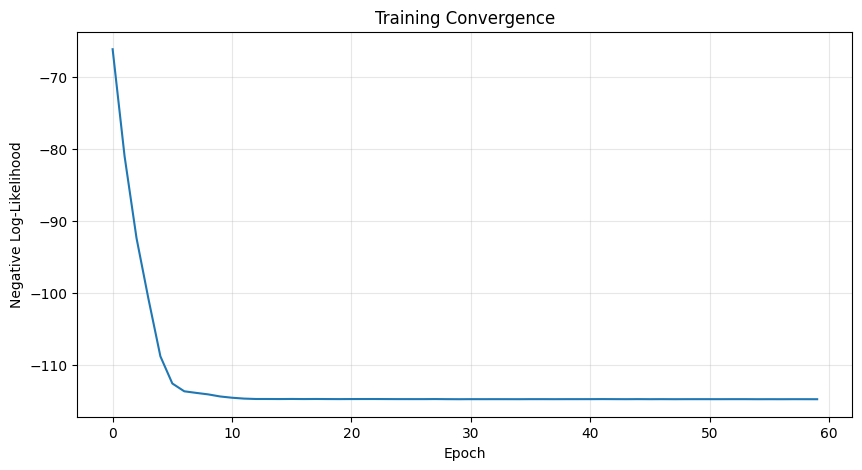


FITTED vs TRUE PARAMETERS

Diffusion Coefficients (µm²/s):
  True:   [0.05 0.3 ]
  Fitted: [0.0375 0.2856]

Localization Errors (µm):
  True:   0.02
  Fitted: [0.019  0.0243]

State Fractions:
  True:   [0.4 0.6]
  Fitted: [0.6058 0.3941]

Transition Rates:
  True:
[[0.   0.04]
 [0.06 0.  ]]
  Fitted:
[[0.9612 0.0388]
 [0.0574 0.9426]]


In [10]:

# %%
# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'])
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('Training Convergence')
ax.grid(True, alpha=0.3)
plt.savefig('training_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Extract fitted parameters
fitted_params = exatrack.get_model_params(model)

print("\n" + "="*60)
print("FITTED vs TRUE PARAMETERS")
print("="*60)

# Diffusion coefficients
fitted_d = np.exp(model.weights[0][:, 1].numpy())
fitted_D = fitted_d**2 / (2 * dt)
print(f"\nDiffusion Coefficients (µm²/s):\n  True:   {Ds}\n  Fitted: {np.round(fitted_D, 4)}")

# Localization errors
fitted_LocErr = np.exp(model.weights[0][:, 0].numpy())
print(f"\nLocalization Errors (µm):\n  True:   {LocErr}\n  Fitted: {np.round(fitted_LocErr, 4)}")

# Fractions
fitted_fractions = tf.math.softmax(model.weights[2][0]).numpy()
print(f"\nState Fractions:\n  True:   {Fs}\n  Fitted: {np.round(fitted_fractions[:-1], 4)}")

# Transition rates
fitted_transition_shapes = np.exp(model.weights[5].numpy())
fitted_transition_rates = tf.math.softmax(model.weights[4], axis=1).numpy() * fitted_transition_shapes
print(f"\nTransition Rates:\n  True:\n{transition_matrix}\n  Fitted:\n{np.round(fitted_transition_rates, 4)}")


## Part 3: Fitting with Unknown Motion Types

In real experiments, we often don't know the type of motion a priori.
ExaTrack can automatically determine whether each state exhibits
confined or directed motion using the `Model_finder` function.

This function tests different motion type hypotheses and selects
the best model based on the log-likelihood.

In [11]:
# %%
# Define initial parameter guesses for 2 states
nb_states = 2

# Calculate d from diffusion coefficient: d = sqrt(2 * D * dt)
d_values = np.sqrt(2 * Ds * dt)

# Parameter array: [log(LocErr), log(d), anomalous_param, log(q), model_type]
# model_type: 0 = confined, 1 = directed
params = np.array([[np.log(0.025), np.log(0.1), np.log(0.1), np.log(0.01), 1],  # Directed state
                   [np.log(0.025), np.log(0.5), np.log(0.01), np.log(0.01), 1]], dtype='float64')  # Directed state

# Initial parameters (position spread at track start)
initial_params = np.array([[np.log(1.0)],
                           [np.log(1.0)]], dtype='float64')

# Initial fractions (will be optimized, using softmax internally)
# Last element accounts for mislinking probability
initial_fractions = np.array([[0.0, 0.0, -5.0]], dtype='float64')

# Transition rates (log-space, converted via softmax)
transition_rates = np.array([[4.0, 0.0],
                             [0.0, 4.0]], dtype='float64')

# Transition shapes - FIXED to 1 for exponential dwell times
# We use log(1) = 0 and then fix these parameters
transition_shapes = np.array([[0.0, 0.0],
                              [0.0, 0.0]], dtype='float64')

print("Initial Parameters:")
print(f"  params shape: {params.shape}")
print(f"  initial_params shape: {initial_params.shape}")
print(f"  transition_rates shape: {transition_rates.shape}")
print(f"  transition_shapes shape: {transition_shapes.shape}")


Initial Parameters:
  params shape: (2, 5)
  initial_params shape: (2, 1)
  transition_rates shape: (2, 2)
  transition_shapes shape: (2, 2)


### Creating Masks to Fix Parameters

To fix certain parameters during optimization (like transition shapes = 1),
we create "vary" masks where 0 means fixed and 1 means variable.

In [12]:
# Create vary masks to fix certain parameters
# vary_params: which recurrent parameters to optimize
vary_params = np.ones(params.shape, dtype='float64')
vary_params[:, 4] = 0  # Fix model type (we know it's confined motion)

# vary_transition_shapes: fix shapes to 1 (exponential)
vary_transition_shapes = np.zeros(transition_shapes.shape, dtype='float64')

# Allow other parameters to vary
vary_initial_params = np.ones(initial_params.shape, dtype='float64')
vary_initial_fractions = np.ones(initial_fractions.shape, dtype='float64')
vary_transition_rates = np.ones(transition_rates.shape, dtype='float64')

print("Parameter Variation Masks:")
print(f"  vary_params:\n{vary_params}")
print(f"  vary_transition_shapes (all zeros = fixed):\n{vary_transition_shapes}")


Parameter Variation Masks:
  vary_params:
[[1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0.]]
  vary_transition_shapes (all zeros = fixed):
[[0. 0.]
 [0. 0.]]


In [22]:
# Model hyperparameters
batch_size = 100
sequence_length = 3  # Number of past states to consider
max_linking_distance = 0.5  # Maximum expected mislinking distance
estimated_density = 0.001  # Track density (for mislinking model)
track_len = max_track_len

# Training configuration
epochs = 60
learning_rate = 1/30
decay_rate = 0.01
decay_threshold = 30 * nb_tracks // batch_size

model, pred_model = exatrack.Model_finder(
    tracks=tracks,
    masks=track_masks,
    sequence_length=sequence_length,
    nb_states=nb_states,
    params=params,
    initial_params=initial_params,
    initial_fractions=initial_fractions,
    transition_shapes=transition_shapes,
    transition_rates=transition_rates,
    max_linking_distance=max_linking_distance,
    estimated_density=estimated_density,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    decay_threshold=decay_threshold,
    decay_rate=decay_rate,
    device=DEVICE,
    shuffle=True,
    verbose=1,
    vary_params=vary_params,
    vary_initial_params=vary_initial_params,
    vary_initial_fractions=vary_initial_fractions,
    vary_transition_shapes=vary_transition_shapes,
    vary_transition_rates=vary_transition_rates)

0
Checking that the recurrent next Gaussians have the same form than the initial next gaussians: True
0 Tensor("sub_6:0", shape=(100, 9), dtype=float64)
Tensor("add_7:0", shape=(100, 9), dtype=float64)
0 Tensor("sub_11:0", shape=(100, 9), dtype=float64)
1 Tensor("sub_17:0", shape=(100, 9), dtype=float64)
Tensor("add_14:0", shape=(100, 9), dtype=float64)
1 Tensor("sub_22:0", shape=(100, 9), dtype=float64)
2 Tensor("sub_28:0", shape=(100, 9), dtype=float64)
Tensor("add_21:0", shape=(100, 9), dtype=float64)
2 Tensor("sub_33:0", shape=(100, 9), dtype=float64)
3 Tensor("sub_39:0", shape=(100, 9), dtype=float64)
Tensor("add_28:0", shape=(100, 9), dtype=float64)
3 Tensor("sub_44:0", shape=(100, 9), dtype=float64)
4 Tensor("sub_50:0", shape=(100, 9), dtype=float64)
Tensor("add_35:0", shape=(100, 9), dtype=float64)
4 Tensor("sub_55:0", shape=(100, 9), dtype=float64)
5 Tensor("sub_61:0", shape=(100, 9), dtype=float64)
Tensor("add_42:0", shape=(100, 9), dtype=float64)
5 Tensor("sub_66:0", shape=(

### Analyzing the Fitted Model

Let's examine the fitted parameters and compare them to the ground truth.

In [26]:
# Analyze the found model
found_params = exatrack.get_model_params(model)
print("\n" + "="*60)
print("MODEL FINDER RESULTS")
print("="*60)

print(f"\nDetected Motion Types: {found_params['Model types']}\n  (True: the first state should be confined and the second can be either)")
print(f"\nFitted Anomalous Factors: {found_params['anomalous factors']}")
print(f"\nDiffusion Parameters (d): {found_params['d']}\nLocalization Errors: {found_params['Localization errors']}")
print(f"\nState Fractions: {found_params['Fractions']}")



MODEL FINDER RESULTS

Detected Motion Types: ['Confined motion' 'Confined motion']
  (True: the first state should be confined and the second can be either)

Fitted Anomalous Factors: [0.306, 0.001]

Diffusion Parameters (d): [0.038, 0.109]
Localization Errors: [0.019, 0.021]

State Fractions: [0.621, 0.379, 0.0]


## Part 4: State Labeling

After fitting the model, we want to assign states to each position in each track.
This is done using the prediction model which outputs state probabilities.

State labeling enables:
- Visualizing which parts of tracks are in which state
- Computing state-specific statistics
- Understanding transition dynamics

In [13]:
# Get state predictions using the prediction model
print("Computing state predictions...")

with tf.device(DEVICE):
    state_predictions = pred_model.predict((tracks, track_masks), batch_size=batch_size)

print(f"State predictions shape: {state_predictions.shape}")
print(f"  (n_tracks, track_len, n_states+1)")
print(f"  Last state dimension is mislinking probability")


Computing state predictions...
10/10 [==============================] - 83s 3s/step
State predictions shape: (1000, 50, 3)
  (n_tracks, track_len, n_states+1)
  Last state dimension is mislinking probability



Most likely states shape: (1000, 50)


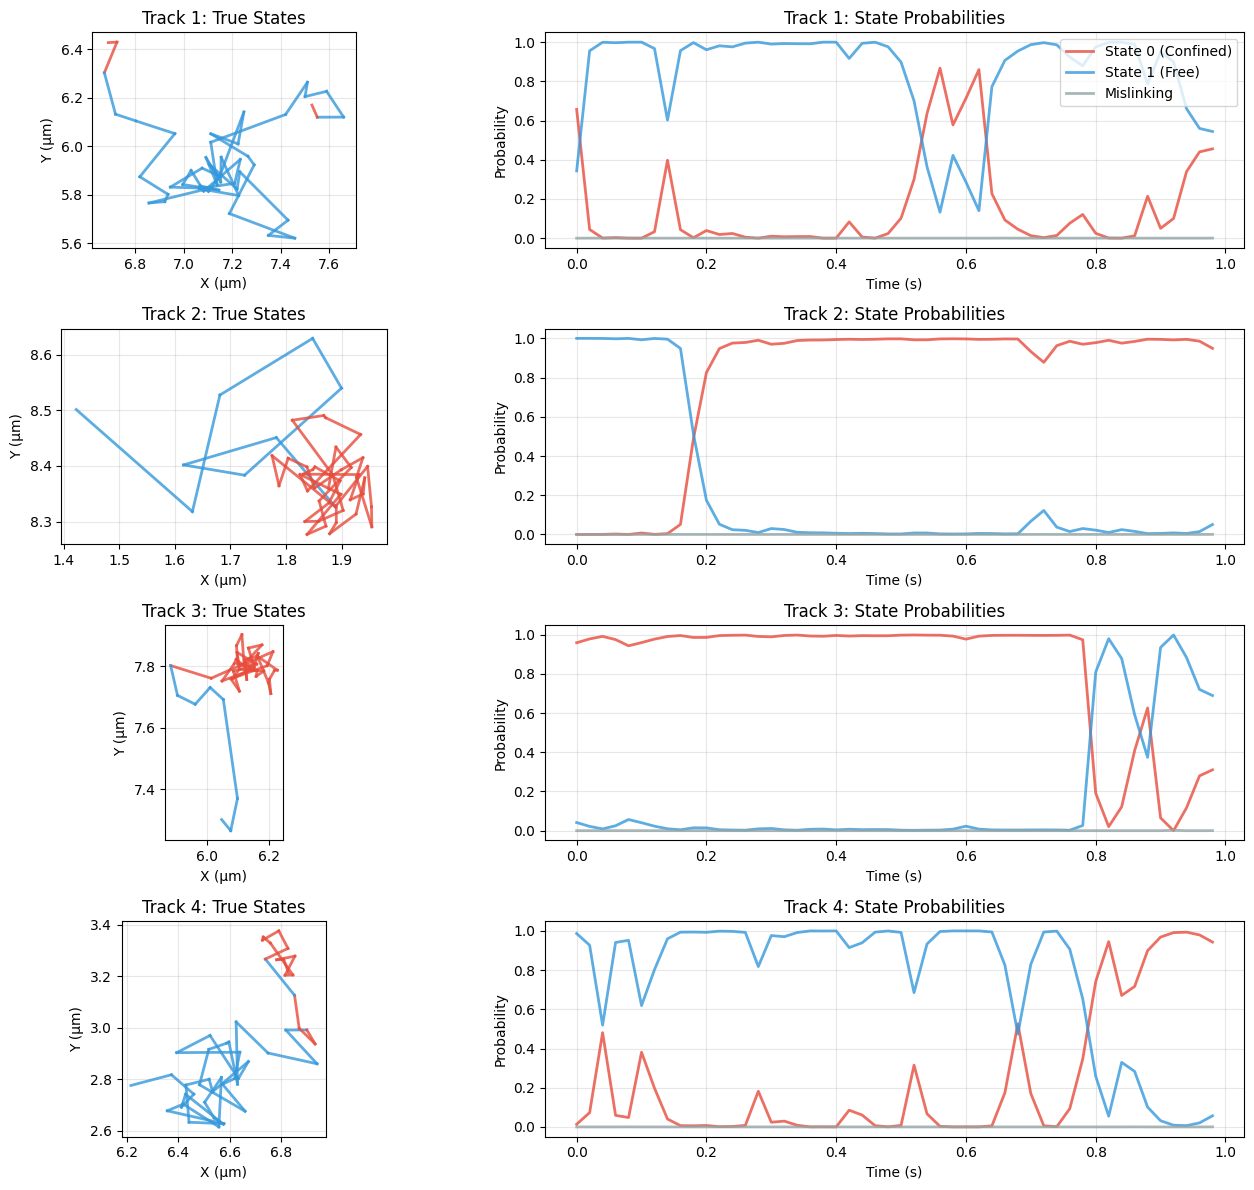

In [28]:
# Correct for padding in predictions
exatrack.correct_state_predictions_padding(state_predictions, track_masks, sequence_length)

# Get the most likely state for each position
most_likely_states = np.argmax(state_predictions, axis=-1)

print(f"\nMost likely states shape: {most_likely_states.shape}")# Visualize state predictions for example tracks
def plot_state_predictions(tracks_data, true_states, pred_probs, masks, n_examples=4):
    """Plot tracks with true states and predicted state probabilities."""
    fig, axes = plt.subplots(n_examples, 2, figsize=(14, 3*n_examples))
    
    colors = ['#e74c3c', '#3498db', '#95a5a6']  # Confined, Free, Mislinking
    state_names = ['State 0 (Confined)', 'State 1 (Free)', 'Mislinking']
    
    for idx in range(n_examples):
        # Left plot: Track colored by true state
        ax1 = axes[idx, 0]
        track = tracks_data[idx, 0, :, 0, 0, :]  # Extract actual positions
        state = true_states[idx].astype(int)
        mask = masks[idx].astype(bool)
        n_points = int(np.sum(mask))
        
        for i in range(n_points - 1):
            ax1.plot(track[i:i+2, 0], track[i:i+2, 1], 
                    color=colors[state[i]], linewidth=2, alpha=0.8)
        
        ax1.set_xlabel('X (µm)')
        ax1.set_ylabel('Y (µm)')
        ax1.set_title(f'Track {idx+1}: True States')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)
        
        # Right plot: State probability over time
        ax2 = axes[idx, 1]
        time = np.arange(n_points) * dt
        
        for s in range(pred_probs.shape[-1]):
            ax2.plot(time, pred_probs[idx, :n_points, s], 
                    color=colors[s] if s < len(colors) else 'gray',
                    label=state_names[s] if s < len(state_names) else f'State {s}',
                    linewidth=2, alpha=0.8)
        
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Probability')
        ax2.set_title(f'Track {idx+1}: State Probabilities')
        ax2.set_ylim(-0.05, 1.05)
        ax2.grid(True, alpha=0.3)
        if idx == 0:
            ax2.legend(loc='upper right')
    
    plt.tight_layout()
    return fig

fig = plot_state_predictions(tracks, all_states, state_predictions, track_masks)
plt.savefig('state_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Calculate state labeling accuracy
def calculate_accuracy(true_states, pred_probs, masks):
    """Calculate accuracy of state predictions."""
    pred_states = np.argmax(pred_probs[:, :, :-1], axis=-1)  # Exclude mislinking
    
    correct = 0
    total = 0
    
    for i in range(len(true_states)):
        n_points = int(np.sum(masks[i]))
        correct += np.sum(true_states[i, :n_points] == pred_states[i, :n_points])
        total += n_points
    
    return correct / total

accuracy = calculate_accuracy(all_states, state_predictions, track_masks)
print(f"\nState Labeling Accuracy: {accuracy*100:.1f}%")
# Convert predictions to DataFrame format for further analysis
# This creates a table with positions, frames, track IDs, and state probabilities

# Create dummy frame and track ID lists for demonstration
frame_list = [np.arange(int(np.sum(m))) for m in track_masks]
track_ID_list = [np.array([i] * int(np.sum(m))) for i, m in enumerate(track_masks)]
track_list = [all_tracks[i, :int(np.sum(track_masks[i]))] for i in range(len(all_tracks))]

# Create DataFrame
df = exatrack.ExaTrack_2_DataFrame(
    track_list=track_list,
    frame_list=frame_list,
    track_ID_list=track_ID_list,
    opt_metrics={},
    state_preds=state_predictions,
    all_masks=track_masks)

print("\nDataFrame Preview:")
print(df.head(10))

# Save to CSV
df.to_csv('state_labeled_tracks.csv', index=False)
print("\nSaved state-labeled tracks to 'state_labeled_tracks.csv'")



State Labeling Accuracy: 93.4%

DataFrame Preview:
   POSITION_X  POSITION_Y  FRAME  TRACK_ID   STATE_0   STATE_1  \
0    6.687746    6.428409    0.0       0.0  0.656883  0.343117   
1    6.723491    6.430339    1.0       0.0  0.044223  0.955701   
2    6.671561    6.303895    2.0       0.0  0.000543  0.999331   
3    6.717560    6.132980    3.0       0.0  0.003058  0.996934   
4    6.801552    6.105165    4.0       0.0  0.000142  0.999832   
5    6.962484    6.052797    5.0       0.0  0.000009  0.999935   
6    6.817894    5.874786    6.0       0.0  0.032924  0.967021   
7    6.934294    5.802181    7.0       0.0  0.397507  0.602481   
8    6.920898    5.771895    8.0       0.0  0.043254  0.956733   
9    6.855693    5.766415    9.0       0.0  0.002147  0.997471   

   STATE_MISLABELED  
0      8.152278e-10  
1      7.629569e-05  
2      1.261054e-04  
3      8.410591e-06  
4      2.591563e-05  
5      5.642916e-05  
6      5.522137e-05  
7      1.287748e-05  
8      1.251918e-05  
9

## Part 5: Determining the Number of States

A critical question in HMM analysis is: how many states are present in the data?
ExaTrack provides the `get_number_of_states` function which:

1. Starts with a specified maximum number of states
2. Fits models with decreasing numbers of states
3. Uses information criteria (AIC, BIC) to select the optimal model

This helps avoid overfitting while capturing the true complexity of the data.

In [14]:
# Prepare parameters for a maximum of 4 states
max_states = 4
sequence_length = 4
max_linking_distance = 1
estimated_density = 0.001  # Track density (for mislinking model)
batch_size = 100

# Initialize with generic guesses
params = np.array([[np.log(0.025), np.log(0.01), np.log(0.1), np.log(0.01), 0],
                          [np.log(0.025), np.log(0.05), np.log(0.1), np.log(0.01), 1],
                          [np.log(0.025), np.log(0.2), np.log(0.1), np.log(0.01), 0],
                          [np.log(0.025), np.log(0.8), np.log(0.1), np.log(0.01), 1]], dtype='float64')

initial_params = np.array([[np.log(1.0)],
                                  [np.log(1.0)],
                                  [np.log(1.0)],
                                  [np.log(1.0)]], dtype='float64')

# Equal initial fractions
initial_fractions = np.array([[0.0, 0.0, 0.0, 0.0, -5.0]], dtype='float64')

# Transition matrices
transition_rates = 4 * np.eye(max_states, dtype='float64')
transition_shapes = np.zeros((max_states, max_states), dtype='float64')

# Create vary masks to fix certain parameters
# vary_params: which recurrent parameters to optimize
vary_params = True
# vary_transition_shapes: fix shapes to 1 (exponential)
vary_transition_shapes = False

# Allow other parameters to vary
vary_initial_params = True
vary_initial_fractions = True
vary_transition_rates = True

print("Testing models with 1 to 4 states to find optimal number...")
print("This task can take a few minutes to start...")

Testing models with 1 to 4 states to find optimal number...
This task can take a few minutes to start...


In [15]:
# Run state number determination
results = exatrack.get_number_of_states(
    tracks=all_tracks,
    track_masks=None,
    params=params,
    initial_params=initial_params,
    transition_shapes=transition_shapes,
    transition_rates=transition_rates,
    initial_fractions=initial_fractions,
    nb_dims=nb_dims,
    sequence_length=sequence_length,
    max_linking_distance=max_linking_distance,
    estimated_density=estimated_density,
    epochs=60,
    epoch_decay=30,
    batch_size=batch_size,
    device=DEVICE,
    vary_params=vary_params,
    vary_initial_params=vary_initial_params,
    vary_initial_fractions=vary_initial_fractions,
    vary_transition_shapes=vary_transition_shapes,
    vary_transition_rates=vary_transition_rates)


Training model with 4 states
Tensor("all_params:0", shape=(4, 5), dtype=float64)
nb_states 4
0
Checking that the recurrent next Gaussians have the same form than the initial next gaussians: True
Tensor("all_params:0", shape=(5, 5), dtype=float64)
nb_states 5
1...
1...
1...
1...
1...
2...
2...
transition_shapes Tensor("transition_shapes:0", shape=(4, 4), dtype=float64)
LP Tensor("LP:0", shape=(100, 20), dtype=float64)
1...
1...
1...
1...
1...
1...
2...
2...
0 Tensor("sub_6:0", shape=(100, 20), dtype=float64)
Tensor("add_7:0", shape=(100, 20), dtype=float64)
0 Tensor("sub_11:0", shape=(100, 20), dtype=float64)
1 Tensor("sub_17:0", shape=(100, 20), dtype=float64)
Tensor("add_14:0", shape=(100, 20), dtype=float64)
1 Tensor("sub_22:0", shape=(100, 20), dtype=float64)
2 Tensor("sub_28:0", shape=(100, 20), dtype=float64)
Tensor("add_21:0", shape=(100, 20), dtype=float64)
2 Tensor("sub_33:0", shape=(100, 20), dtype=float64)
3 Tensor("sub_39:0", shape=(100, 20), dtype=float64)
Tensor("add_28:0

C:\Users\Franc\anaconda3\envs\PyExaTrack\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("Adam/gradients/PartitionedCall_1:6", shape=(100,), dtype=int32), values=Tensor("Adam/gradients/PartitionedCall_1:5", shape=(100,), dtype=float64), dense_shape=Tensor("Adam/gradients/PartitionedCall_1:7", shape=(1,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(
C:\Users\Franc\anaconda3\envs\PyExaTrack\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("Adam/gradients/PartitionedCall_1:9", shape=(100,), dtype=int32), values=Tensor("Adam/gradients/PartitionedCall_1:8", shape=(100,), dtype=float64), dense_shape=Tensor("Adam/gradients/PartitionedCall_1:10", shape=(1,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of 

10/10 [==============================] - ETA: 0s - loss: -70.7518 {'Model types': array(['Confined motion', 'Directed motion', 'Confined motion',
       'Directed motion'], dtype='<U15'), 'anomalous factors': [0.092, 0.134, 0.086, 0.134], 'Localization errors': [0.026, 0.026, 0.024, 0.026], 'd': [0.01, 0.053, 0.187, 0.758], 'transition rates': [0.945, 0.019, 0.018, 0.017, 0.017, 0.951, 0.017, 0.016, 0.019, 0.02, 0.945, 0.017, 0.018, 0.019, 0.019, 0.943], 'transition shapes': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'Fractions': [0.257, 0.262, 0.243, 0.237, 0.002]}
10/10 [==============================] - 858s 48s/step - loss: -70.7518
Epoch 2/60
 8/10 [=======================>......] - ETA: 1:39 - loss: -77.0301

KeyboardInterrupt: 

In [ ]:
# Analyze results
print("\n" + "="*60)
print("MODEL SELECTION RESULTS")
print("="*60)

best_nb_states = results['best_nb_states']
all_results = results['all_results']

print(f"\nResults for each model:")
for n_states in sorted(all_results.keys(), reverse=True):
    r = all_results[n_states]
    print(f"  {n_states} states: LL={r['log_likelihood']:.1f}, "
          f"AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

print(f"\n★ Optimal number of states: {best_nb_states}")
print(f"  (True number of states: 2)")

In [ ]:
# Plot model selection results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

n_states_list = sorted(all_results.keys())
ll_values = [all_results[n]['log_likelihood'] for n in n_states_list]
aic_values = [all_results[n]['aic'] for n in n_states_list]
bic_values = [all_results[n]['bic'] for n in n_states_list]

# Log-likelihood
ax = axes[0]
ax.plot(n_states_list, ll_values, 'o-', markersize=10, linewidth=2)
ax.axvline(x=2, color='green', linestyle='--', label='True # states', alpha=0.7)
ax.set_xlabel('Number of States')
ax.set_ylabel('Log-Likelihood')
ax.set_title('Log-Likelihood vs Number of States')
ax.legend()
ax.grid(True, alpha=0.3)

# AIC
ax = axes[1]
ax.plot(n_states_list, aic_values, 'o-', markersize=10, linewidth=2, color='orange')
ax.axvline(x=2, color='green', linestyle='--', label='True # states', alpha=0.7)
ax.axvline(x=best_nb_states, color='red', linestyle=':', label='Selected (BIC)', alpha=0.7)
ax.set_xlabel('Number of States')
ax.set_ylabel('AIC')
ax.set_title('AIC vs Number of States')
ax.legend()
ax.grid(True, alpha=0.3)

# BIC
ax = axes[2]
ax.plot(n_states_list, bic_values, 'o-', markersize=10, linewidth=2, color='purple')
ax.axvline(x=2, color='green', linestyle='--', label='True # states', alpha=0.7)
ax.axvline(x=best_nb_states, color='red', linestyle=':', label='Selected (BIC)', alpha=0.7)
ax.set_xlabel('Number of States')
ax.set_ylabel('BIC')
ax.set_title('BIC vs Number of States')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_selection.png', dpi=150, bbox_inches='tight')
plt.show()## Summary


## Summary

This tutorial demonstrated the main functionalities of ExaTrack:

1. **Data Simulation**: Generate synthetic tracks with multiple diffusion states
   and known transition kinetics using `anomalous_diff_transition`.

2. **Basic Model Fitting**: Fit a model with known motion types and fixed
   transition shapes using `build_model` and standard Keras training.

3. **Motion Type Discovery**: Use `Model_finder` to automatically determine
   whether states exhibit confined or directed motion.

4. **State Labeling**: Get state probabilities for each track position using
   the prediction model, enabling visualization and downstream analysis.

5. **Model Selection**: Use `get_number_of_states` with information criteria
   (AIC/BIC) to determine the optimal number of states.

### Key Tips:

- Start with reasonable initial parameter guesses based on your data
- Use GPU acceleration for faster training with large datasets
- The `sequence_length` parameter trades off accuracy vs computational cost
- Always validate results with synthetic data before analyzing experiments
- Consider biological priors when interpreting motion types